<a href="https://colab.research.google.com/github/TetianaMar-888/Child-internet-use-datamining/blob/main/notebooks/DM2_02_advanced_ml_xai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

DATA = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/data'
REPORTS = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/reports'

data = pd.read_csv(f'{DATA}/cmi_internet.csv')
dictionary = pd.read_csv(f'{DATA}/data_dictionary.csv')

# --- Module 0 corrections ---
cgas_mask = data['CGAS-CGAS_Score'] > 100
data.loc[cgas_mask, 'CGAS-CGAS_Score'] = data.loc[cgas_mask, 'CGAS-CGAS_Score'] / 10

for col in ['Physical-BMI', 'Physical-Weight', 'Physical-Diastolic_BP', 'Physical-Systolic_BP']:
    data[col] = data[col].replace(0, np.nan)

data['BIA-BIA_Fat'] = data['BIA-BIA_Fat'].where(data['BIA-BIA_Fat'].between(0, 100))

# --- Module 1 outlier treatment: 3×q99 on BIA numeric fields ---
bia_numeric = [c for c in data.columns if c.startswith('BIA-BIA_')]
for col in bia_numeric:
    q99 = data[col].quantile(0.99)
    data.loc[data[col] > q99 * 3, col] = np.nan

print("Shape:", data.shape)
print("CGAS max:", data['CGAS-CGAS_Score'].max())
print("BIA-BIA_TBW max:", round(data['BIA-BIA_TBW'].max(), 2))
print("\nTarget distribution (4-class sii):")
print(data['sii'].value_counts().sort_index())

Mounted at /content/drive
Shape: (8460, 82)
CGAS max: 99.9
BIA-BIA_TBW max: 304.99

Target distribution (4-class sii):
sii
0.0    5833
1.0    1587
2.0     952
3.0      88
Name: count, dtype: int64


In [ ]:
classification_features = [
    'Basic_Demos-Age', 'Basic_Demos-Sex',
    'CGAS-CGAS_Score',
    'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
    'Physical-Systolic_BP', 'Physical-HeartRate',
    'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
    'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU',
    'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL',
    'BIA-BIA_BMI', 'BIA-BIA_Fat', 'BIA-BIA_FFMI', 'BIA-BIA_SMM',
    'BIA-BIA_TBW', 'BIA-BIA_ICW', 'BIA-BIA_ECW', 'BIA-BIA_BMR', 'BIA-BIA_DEE',
    'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total',
    'SDS-SDS_Total_Raw',
    'PreInt_EduHx-computerinternet_hoursday',
]
classification_features = [c for c in classification_features if c in data.columns]

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(
    imputer.fit_transform(data[classification_features]),
    columns=classification_features,
    index=data.index
)
y = data['sii'].astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Target classes: {sorted(y.unique())}")
print(f"Class distribution: {y.value_counts().sort_index().to_dict()}")
print(f"Minority class share: {(y == 3).mean():.4f}")

Feature matrix: (8460, 32)
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Class distribution: {0: 5833, 1: 1587, 2: 952, 3: 88}
Minority class share: 0.0104


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print("\nClass distribution preserved:")
print(pd.DataFrame({
    'train': y_train.value_counts(normalize=True).sort_index().round(4),
    'test': y_test.value_counts(normalize=True).sort_index().round(4),
}))

Train: 6345, Test: 2115

Class distribution preserved:
      train    test
sii                
0    0.6895  0.6894
1    0.1875  0.1877
2    0.1125  0.1125
3    0.0104  0.0104


###Logistic Regression model

In [ ]:
# Quick check: how much does class_weight matter, before committing to full grids?
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix

for cw in [None, 'balanced']:
    lr = LogisticRegression(max_iter=2000, class_weight=cw, random_state=42)
    lr.fit(X_train_scaled, y_train)
    y_pred = lr.predict(X_test_scaled)
    print(f"\nclass_weight={cw}:")
    print(f"  Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")
    print(f"  Per-class F1: {f1_score(y_test, y_pred, average=None).round(3)}")
    print(f"  Class 3 predicted at all: {(y_pred == 3).sum()} times")


class_weight=None:
  Macro F1: 0.248
  Per-class F1: [0.817 0.059 0.116 0.   ]
  Class 3 predicted at all: 1 times

class_weight=balanced:
  Macro F1: 0.292
  Per-class F1: [0.693 0.196 0.231 0.047]
  Class 3 predicted at all: 365 times


In [ ]:
lr_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced'],
    'solver': ['lbfgs', 'saga'],
}

lr_search = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42),
    lr_grid, scoring='f1_macro', cv=5, n_jobs=-1
)
lr_search.fit(X_train_scaled, y_train)

print("Configurations tested:", len(lr_search.cv_results_['params']))
print("Best params:", lr_search.best_params_)
print("Best CV macro-F1:", round(lr_search.best_score_, 4))

lr_best = lr_search.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)

print("\nTest set:")
print(classification_report(y_test, y_pred_lr, digits=3,
                            target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Configurations tested: 16
Best params: {'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best CV macro-F1: 0.2954

Test set:
              precision    recall  f1-score   support

       sii=0      0.806     0.618     0.700      1458
       sii=1      0.238     0.174     0.201       397
       sii=2      0.193     0.282     0.229       238
       sii=3      0.025     0.409     0.047        22

    accuracy                          0.495      2115
   macro avg      0.315     0.371     0.294      2115
weighted avg      0.622     0.495     0.546      2115

Confusion matrix:
[[901 182 190 185]
 [157  69  83  88]
 [ 55  38  67  78]
 [  5   1   7   9]]


In [ ]:
lr_grid_extended = {
    'C': [0.0001, 0.001, 0.01, 0.1],
    'class_weight': ['balanced'],
    'solver': ['lbfgs'],
}
lr_ext = GridSearchCV(LogisticRegression(max_iter=3000, random_state=42),
                      lr_grid_extended, scoring='f1_macro', cv=5, n_jobs=-1)
lr_ext.fit(X_train_scaled, y_train)
print("Best C (extended):", lr_ext.best_params_['C'])
print("Best CV macro-F1:", round(lr_ext.best_score_, 4))
print("\nAll results:")
for c, score in zip(lr_ext.cv_results_['param_C'], lr_ext.cv_results_['mean_test_score']):
    print(f"  C={c}: {score:.4f}")

Best C (extended): 0.001
Best CV macro-F1: 0.2965

All results:
  C=0.0001: 0.2795
  C=0.001: 0.2965
  C=0.01: 0.2954
  C=0.1: 0.2954


In [ ]:
# Fix the final Logistic Regression model with the extended-grid optimum
lr_final = LogisticRegression(C=0.001, class_weight='balanced',
                               solver='lbfgs', max_iter=3000, random_state=42)
lr_final.fit(X_train_scaled, y_train)
y_pred_lr = lr_final.predict(X_test_scaled)
y_proba_lr = lr_final.predict_proba(X_test_scaled)

print("Final Logistic Regression:")
print(classification_report(y_test, y_pred_lr, digits=3,
                            target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']))

# Store results for later comparison across all five models
results = {}
results['Logistic Regression'] = {
    'macro_f1': f1_score(y_test, y_pred_lr, average='macro'),
    'weighted_f1': f1_score(y_test, y_pred_lr, average='weighted'),
    'accuracy': (y_pred_lr == y_test).mean(),
    'per_class_f1': f1_score(y_test, y_pred_lr, average=None),
}
print("\nStored for comparison:", {k: round(v, 3) if isinstance(v, float) else v.round(3)
                                     for k, v in results['Logistic Regression'].items()})

Final Logistic Regression:
              precision    recall  f1-score   support

       sii=0      0.804     0.652     0.720      1458
       sii=1      0.260     0.164     0.201       397
       sii=2      0.204     0.265     0.230       238
       sii=3      0.035     0.591     0.065        22

    accuracy                          0.516      2115
   macro avg      0.326     0.418     0.304      2115
weighted avg      0.627     0.516     0.561      2115


Stored for comparison: {'macro_f1': 0.304, 'weighted_f1': 0.561, 'accuracy': np.float64(0.516), 'per_class_f1': array([0.72 , 0.201, 0.23 , 0.065])}


###Support Vector Machine

In [ ]:
from sklearn.svm import SVC

# probability=True triggers internal Platt-scaling CV and multiplies runtime by ~5.
# Tune without it; refit the winner with probabilities afterwards if ROC curves are needed.
svm_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['rbf'],
    'gamma': ['scale'],
    'class_weight': ['balanced'],
}

svm_search = GridSearchCV(SVC(random_state=42),
                          svm_grid, scoring='f1_macro', cv=3, n_jobs=-1)
svm_search.fit(X_train_scaled, y_train)

print("Configurations tested:", len(svm_search.cv_results_['params']))
print("Best params:", svm_search.best_params_)
print("Best CV macro-F1:", round(svm_search.best_score_, 4))

y_pred_svm = svm_search.best_estimator_.predict(X_test_scaled)
print("\nTest set:")
print(classification_report(y_test, y_pred_svm, digits=3,
                            target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']))

Configurations tested: 3
Best params: {'C': 1.0, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best CV macro-F1: 0.3154

Test set:
              precision    recall  f1-score   support

       sii=0      0.798     0.525     0.633      1458
       sii=1      0.246     0.325     0.280       397
       sii=2      0.216     0.403     0.282       238
       sii=3      0.021     0.182     0.038        22

    accuracy                          0.470      2115
   macro avg      0.320     0.359     0.308      2115
weighted avg      0.621     0.470     0.521      2115



In [ ]:
results['SVM'] = {
    'macro_f1': f1_score(y_test, y_pred_svm, average='macro'),
    'weighted_f1': f1_score(y_test, y_pred_svm, average='weighted'),
    'accuracy': (y_pred_svm == y_test).mean(),
    'per_class_f1': f1_score(y_test, y_pred_svm, average=None),
}
print("SVM stored:", {k: round(v,3) if isinstance(v,float) else v.round(3)
                       for k,v in results['SVM'].items()})

SVM stored: {'macro_f1': 0.308, 'weighted_f1': 0.521, 'accuracy': np.float64(0.47), 'per_class_f1': array([0.633, 0.28 , 0.282, 0.038])}


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 10],
    'class_weight': ['balanced', 'balanced_subsample'],
}

rf_search = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                         rf_grid, scoring='f1_macro', cv=3, n_jobs=-1)
rf_search.fit(X_train, y_train)   # trees don't need scaling

print("Configurations tested:", len(rf_search.cv_results_['params']))
print("Best params:", rf_search.best_params_)
print("Best CV macro-F1:", round(rf_search.best_score_, 4))

y_pred_rf = rf_search.best_estimator_.predict(X_test)
print("\nTest set:")
print(classification_report(y_test, y_pred_rf, digits=3,
                            target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']))

Configurations tested: 24
Best params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV macro-F1: 0.3492

Test set:
              precision    recall  f1-score   support

       sii=0      0.799     0.717     0.756      1458
       sii=1      0.295     0.297     0.296       397
       sii=2      0.245     0.395     0.302       238
       sii=3      0.043     0.045     0.044        22

    accuracy                          0.595      2115
   macro avg      0.346     0.364     0.350      2115
weighted avg      0.634     0.595     0.611      2115



In [ ]:
results['Random Forest'] = {
    'macro_f1': f1_score(y_test, y_pred_rf, average='macro'),
    'weighted_f1': f1_score(y_test, y_pred_rf, average='weighted'),
    'accuracy': (y_pred_rf == y_test).mean(),
    'per_class_f1': f1_score(y_test, y_pred_rf, average=None),
}

# Feature importance — the guidelines ask explicitly what this reveals
rf_best = rf_search.best_estimator_
importances = pd.Series(rf_best.feature_importances_, index=classification_features)
print("Top 15 features by importance:")
print(importances.sort_values(ascending=False).head(15).round(4))
print(f"\nFeatures with importance < 0.01: {(importances < 0.01).sum()} of {len(importances)}")

Top 15 features by importance:
Physical-Height         0.0602
SDS-SDS_Total_Raw       0.0560
Physical-Weight         0.0517
Physical-BMI            0.0474
Basic_Demos-Age         0.0453
Physical-Systolic_BP    0.0416
BIA-BIA_DEE             0.0406
BIA-BIA_TBW             0.0400
Physical-HeartRate      0.0394
BIA-BIA_SMM             0.0385
CGAS-CGAS_Score         0.0381
BIA-BIA_ECW             0.0356
BIA-BIA_ICW             0.0346
BIA-BIA_BMI             0.0324
FGC-FGC_GSND            0.0317
dtype: float64

Features with importance < 0.01: 2 of 32


###Gradient Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoosting is substantially faster than GradientBoostingClassifier
# on this many samples, and handles the multiclass case natively.
gb_grid = {
    'max_iter': [200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [20, 50],
}

gb_search = GridSearchCV(HistGradientBoostingClassifier(random_state=42),
                         gb_grid, scoring='f1_macro', cv=3)
gb_search.fit(X_train, y_train)

print("Configurations tested:", len(gb_search.cv_results_['params']))
print("Best params:", gb_search.best_params_)
print("Best CV macro-F1:", round(gb_search.best_score_, 4))

y_pred_gb = gb_search.best_estimator_.predict(X_test)
print("\nTest set:")
print(classification_report(y_test, y_pred_gb, digits=3,
                            target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']))

Configurations tested: 12
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200, 'min_samples_leaf': 50}
Best CV macro-F1: 0.3016

Test set:
              precision    recall  f1-score   support

       sii=0      0.736     0.931     0.822      1458
       sii=1      0.359     0.151     0.213       397
       sii=2      0.359     0.155     0.217       238
       sii=3      0.000     0.000     0.000        22

    accuracy                          0.687      2115
   macro avg      0.364     0.309     0.313      2115
weighted avg      0.615     0.687     0.631      2115



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_w = compute_sample_weight(class_weight='balanced', y=y_train)

gb_weighted = HistGradientBoostingClassifier(
    learning_rate=0.1, max_depth=5, max_iter=200,
    min_samples_leaf=50, random_state=42
)
gb_weighted.fit(X_train, y_train, sample_weight=sample_w)
y_pred_gbw = gb_weighted.predict(X_test)

print("Gradient Boosting WITH balanced sample weights:")
print(classification_report(y_test, y_pred_gbw, digits=3, zero_division=0,
                            target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']))
print(f"Macro F1 without weights: {f1_score(y_test, y_pred_gb, average='macro'):.3f}")
print(f"Macro F1 with weights:    {f1_score(y_test, y_pred_gbw, average='macro'):.3f}")

Gradient Boosting WITH balanced sample weights:
              precision    recall  f1-score   support

       sii=0      0.787     0.726     0.755      1458
       sii=1      0.284     0.330     0.305       397
       sii=2      0.240     0.290     0.262       238
       sii=3      0.048     0.045     0.047        22

    accuracy                          0.595      2115
   macro avg      0.339     0.348     0.342      2115
weighted avg      0.623     0.595     0.608      2115

Macro F1 without weights: 0.313
Macro F1 with weights:    0.342


In [ ]:
results['Gradient Boosting'] = {
    'macro_f1': f1_score(y_test, y_pred_gbw, average='macro'),
    'weighted_f1': f1_score(y_test, y_pred_gbw, average='weighted'),
    'accuracy': (y_pred_gbw == y_test).mean(),
    'per_class_f1': f1_score(y_test, y_pred_gbw, average=None, zero_division=0),
}

###Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'alpha': [0.0001, 0.01, 1.0],          # L2 regularisation strength
    'learning_rate_init': [0.001],
    'early_stopping': [True],               # convergence criterion against overfitting
}

mlp_search = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42, n_iter_no_change=10, validation_fraction=0.15),
    mlp_grid, scoring='f1_macro', cv=3
)
mlp_search.fit(X_train_scaled, y_train)

print("Configurations tested:", len(mlp_search.cv_results_['params']))
print("Best params:", mlp_search.best_params_)
print("Best CV macro-F1:", round(mlp_search.best_score_, 4))

y_pred_mlp = mlp_search.best_estimator_.predict(X_test_scaled)
print("\nTest set:")
print(classification_report(y_test, y_pred_mlp, digits=3, zero_division=0,
                            target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']))

Configurations tested: 9
Best params: {'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
Best CV macro-F1: 0.2642

Test set:
              precision    recall  f1-score   support

       sii=0      0.716     0.968     0.823      1458
       sii=1      0.375     0.068     0.115       397
       sii=2      0.380     0.113     0.175       238
       sii=3      0.000     0.000     0.000        22

    accuracy                          0.693      2115
   macro avg      0.368     0.287     0.278      2115
weighted avg      0.607     0.693     0.609      2115



In [ ]:
results['Neural Network'] = {
    'macro_f1': f1_score(y_test, y_pred_mlp, average='macro'),
    'weighted_f1': f1_score(y_test, y_pred_mlp, average='weighted'),
    'accuracy': (y_pred_mlp == y_test).mean(),
    'per_class_f1': f1_score(y_test, y_pred_mlp, average=None, zero_division=0),
}

comparison = pd.DataFrame(results).T
per_class = pd.DataFrame(
    [r['per_class_f1'] for r in results.values()],
    index=results.keys(),
    columns=['F1 sii=0', 'F1 sii=1', 'F1 sii=2', 'F1 sii=3']
)
summary = pd.concat([comparison[['accuracy', 'macro_f1', 'weighted_f1']], per_class], axis=1)
print(summary.sort_values('macro_f1', ascending=False).round(3))

                     accuracy  macro_f1 weighted_f1  F1 sii=0  F1 sii=1  \
Random Forest        0.594799  0.349602    0.610941     0.756     0.296   
Gradient Boosting    0.595272  0.342262    0.607847     0.755     0.305   
SVM                  0.469976  0.308161     0.52098     0.633     0.280   
Logistic Regression  0.515839  0.304184    0.560637     0.720     0.201   
Neural Network       0.693144  0.278305    0.608845     0.823     0.115   

                     F1 sii=2  F1 sii=3  
Random Forest           0.302     0.044  
Gradient Boosting       0.262     0.047  
SVM                     0.282     0.038  
Logistic Regression     0.230     0.065  
Neural Network          0.175     0.000  


In [ ]:
mlp_best = mlp_search.best_estimator_
print(f"Iterations run: {mlp_best.n_iter_} (max allowed: 500)")
print(f"Early stopping triggered: {mlp_best.n_iter_ < 500}")
print(f"Best validation score during training: {mlp_best.best_validation_score_:.4f}")

# How much did alpha matter?
print("\nCV score by alpha (averaged over architectures):")
res_df = pd.DataFrame(mlp_search.cv_results_)
print(res_df.groupby('param_alpha')['mean_test_score'].mean().round(4))

Iterations run: 21 (max allowed: 500)
Early stopping triggered: True
Best validation score during training: 0.6775

CV score by alpha (averaged over architectures):
param_alpha
0.0001    0.2518
0.0100    0.2524
1.0000    0.2446
Name: mean_test_score, dtype: float64


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Refit SVM with probability=True — needed for ROC, skipped during tuning for speed
svm_proba = SVC(C=1.0, kernel='rbf', gamma='scale', class_weight='balanced',
                probability=True, random_state=42)
svm_proba.fit(X_train_scaled, y_train)
print("SVM refitted with probability estimates")

# Collect probability predictions from all five models
proba_models = {
    'Logistic Regression': lr_final.predict_proba(X_test_scaled),
    'SVM': svm_proba.predict_proba(X_test_scaled),
    'Random Forest': rf_search.best_estimator_.predict_proba(X_test),
    'Gradient Boosting': gb_weighted.predict_proba(X_test),
    'Neural Network': mlp_search.best_estimator_.predict_proba(X_test_scaled),
}

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

# Macro-average ROC-AUC per model
print("\nMacro-average ROC-AUC (One-vs-Rest):")
auc_results = {}
for name, proba in proba_models.items():
    aucs = [auc(*roc_curve(y_test_bin[:, i], proba[:, i])[:2]) for i in range(4)]
    auc_results[name] = aucs
    print(f"  {name:22s} macro={np.mean(aucs):.3f}  per-class={np.round(aucs, 3)}")

SVM refitted with probability estimates

Macro-average ROC-AUC (One-vs-Rest):
  Logistic Regression    macro=0.676  per-class=[0.693 0.523 0.704 0.786]
  SVM                    macro=0.702  per-class=[0.711 0.643 0.725 0.728]
  Random Forest          macro=0.704  per-class=[0.715 0.652 0.726 0.723]
  Gradient Boosting      macro=0.682  per-class=[0.707 0.635 0.693 0.693]
  Neural Network         macro=0.661  per-class=[0.686 0.615 0.706 0.637]


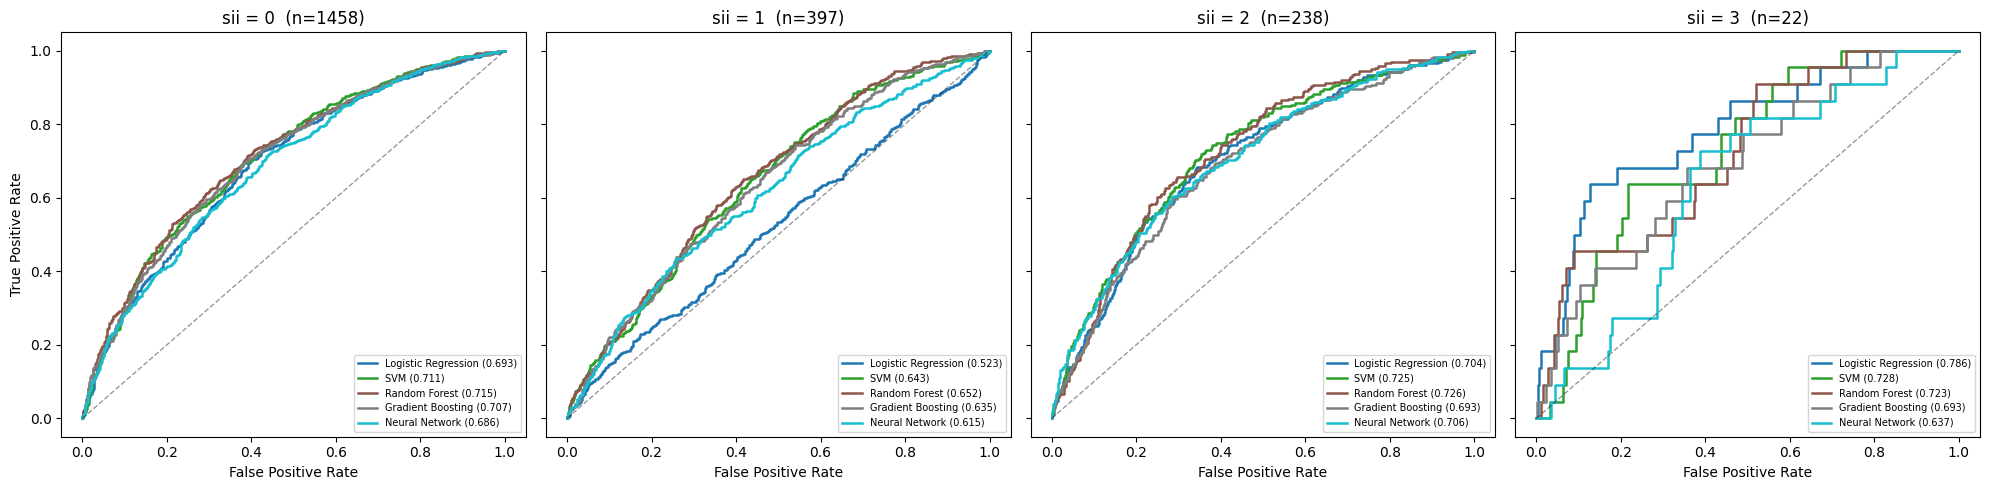

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
colors = plt.cm.tab10(np.linspace(0, 1, 5))

for cls in range(4):
    ax = axes[cls]
    for (name, proba), color in zip(proba_models.items(), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls], proba[:, cls])
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f"{name} ({auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set_xlabel("False Positive Rate")
    ax.set_title(f"sii = {cls}  (n={int(y_test_bin[:, cls].sum())})")
    ax.legend(loc='lower right', fontsize=7)

axes[0].set_ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig(f'{REPORTS}/roc_curves_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
n_estimators_range = [5, 10, 25, 50, 100, 200, 300, 500]
rf_scores = []

for n in n_estimators_range:
    rf_n = RandomForestClassifier(
        n_estimators=n, max_depth=20, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_n.fit(X_train, y_train)
    y_pred_n = rf_n.predict(X_test)
    rf_scores.append({
        'n_estimators': n,
        'macro_f1': f1_score(y_test, y_pred_n, average='macro'),
        'accuracy': (y_pred_n == y_test).mean(),
        'f1_class_1': f1_score(y_test, y_pred_n, average=None, zero_division=0)[1],
        'f1_class_3': f1_score(y_test, y_pred_n, average=None, zero_division=0)[3],
    })

rf_curve = pd.DataFrame(rf_scores)
print(rf_curve.round(4).to_string(index=False))

 n_estimators  macro_f1  accuracy  f1_class_1  f1_class_3
            5    0.3207    0.5267      0.2641      0.0792
           10    0.3290    0.5480      0.2608      0.0750
           25    0.3364    0.5716      0.2750      0.0769
           50    0.3311    0.5797      0.2732      0.0408
          100    0.3496    0.5948      0.2961      0.0444
          200    0.3543    0.5972      0.2922      0.0476
          300    0.3565    0.6014      0.3067      0.0465
          500    0.3521    0.5991      0.2915      0.0417


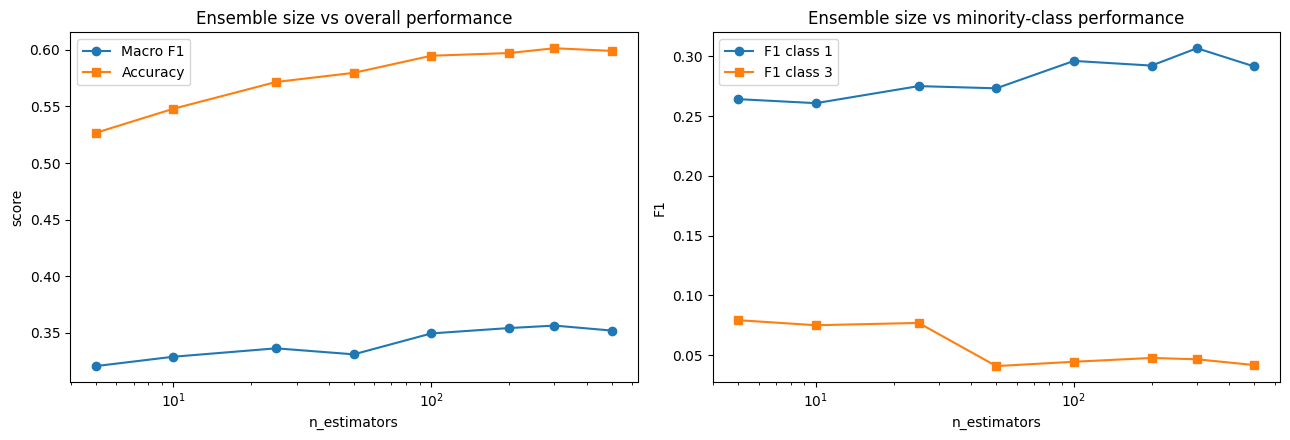

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(rf_curve['n_estimators'], rf_curve['macro_f1'], marker='o', label='Macro F1')
axes[0].plot(rf_curve['n_estimators'], rf_curve['accuracy'], marker='s', label='Accuracy')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('score')
axes[0].set_title('Ensemble size vs overall performance')
axes[0].legend(); axes[0].set_xscale('log')

axes[1].plot(rf_curve['n_estimators'], rf_curve['f1_class_1'], marker='o', label='F1 class 1')
axes[1].plot(rf_curve['n_estimators'], rf_curve['f1_class_3'], marker='s', label='F1 class 3')
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('F1')
axes[1].set_title('Ensemble size vs minority-class performance')
axes[1].legend(); axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig(f'{REPORTS}/ensemble_size_effect.png', dpi=150)
plt.show()

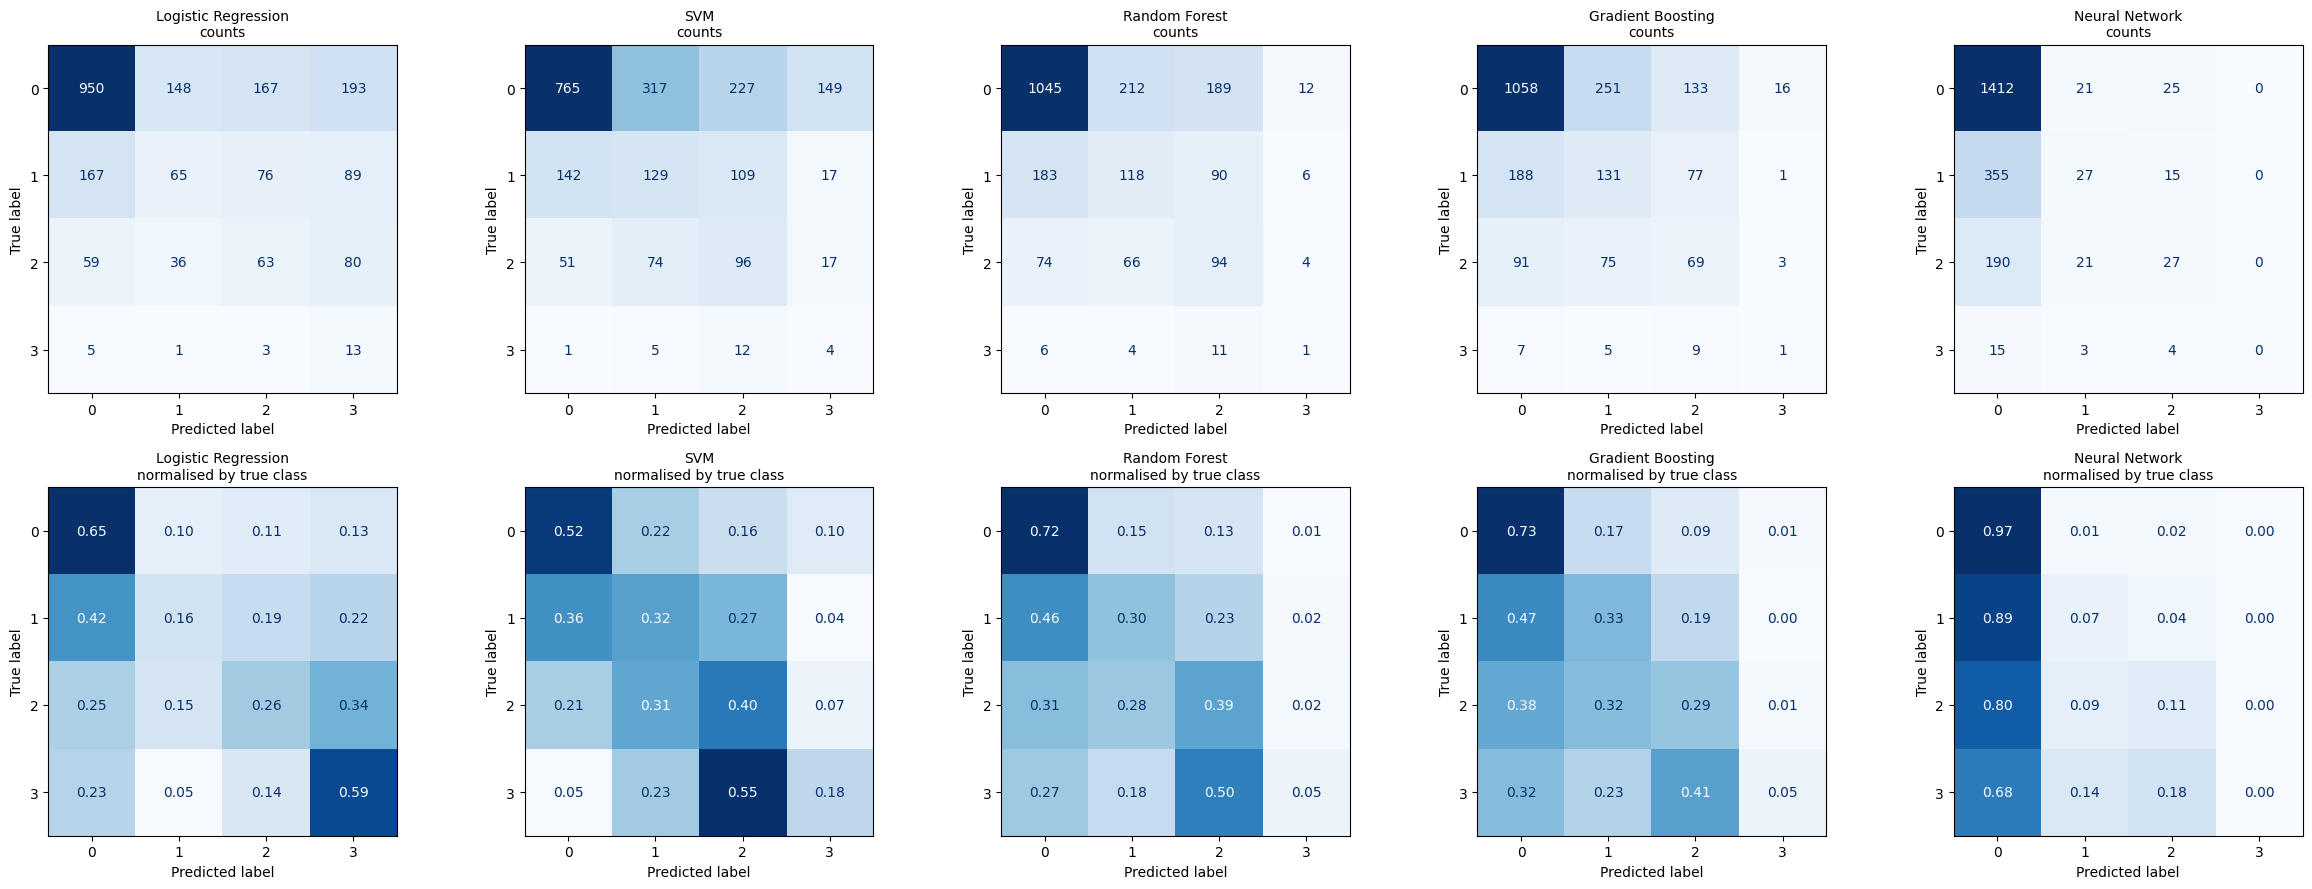

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

predictions = {
    'Logistic Regression': y_pred_lr,
    'SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gbw,
    'Neural Network': y_pred_mlp,
}

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
class_labels = ['0', '1', '2', '3']

for j, (name, y_pred) in enumerate(predictions.items()):
    for i, (norm, fmt) in enumerate([(None, 'd'), ('true', '.2f')]):
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3], normalize=norm)
        ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
            ax=axes[i, j], cmap='Blues', colorbar=False, values_format=fmt)
        axes[i, j].set_title(f"{name}\n{'counts' if norm is None else 'normalised by true class'}",
                             fontsize=10)
        axes[i, j].grid(False)

plt.tight_layout()
plt.savefig(f'{REPORTS}/confusion_matrices_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("Error structure (sii is ordinal — distance of error matters):")
for name, y_pred in predictions.items():
    d = np.abs(y_pred - y_test)
    print(f"  {name:22s} correct {(d==0).mean()*100:5.1f}%  |  "
          f"off by 1: {(d==1).mean()*100:5.1f}%  |  "
          f"off by 2+: {(d>=2).mean()*100:5.1f}%")

Error structure (sii is ordinal — distance of error matters):
  Logistic Regression    correct  51.6%  |  off by 1:  24.1%  |  off by 2+:  24.3%
  SVM                    correct  47.0%  |  off by 1:  31.7%  |  off by 2+:  21.3%
  Random Forest          correct  59.5%  |  off by 1:  26.8%  |  off by 2+:  13.8%
  Gradient Boosting      correct  59.5%  |  off by 1:  28.5%  |  off by 2+:  12.0%
  Neural Network         correct  69.3%  |  off by 1:  19.7%  |  off by 2+:  11.0%


## Advanced Classification

### Task and setup

The multiclass task predicts `sii` across all four severity levels from 32
physical, demographic and questionnaire features. `PCIAT` fields are excluded
throughout as established leakage (Module 0). Missing values are median-imputed
and the split is 75/25, stratified on the target.

The class distribution is severely skewed: 69% / 19% / 11% / 1%, leaving only
66 training examples for class 3. A preliminary check established that this
dominates everything that follows. Logistic Regression without class weighting
achieved macro F1 0.248 and predicted class 3 exactly once across 2,115 test
records; with `class_weight='balanced'` macro F1 rose to 0.292. All subsequent
grids therefore include class weighting where the estimator supports it, and
**macro F1 is used as the selection metric throughout** — accuracy would select
configurations that ignore three of the four classes.

### Results

| Model | Accuracy | Macro F1 | F1 sii=0 | F1 sii=1 | F1 sii=2 | F1 sii=3 | Macro AUC |
|---|---|---|---|---|---|---|---|
| **Random Forest** | 0.595 | **0.350** | 0.756 | 0.296 | 0.302 | 0.044 | **0.704** |
| Gradient Boosting | 0.595 | 0.342 | 0.755 | 0.305 | 0.262 | 0.047 | 0.682 |
| SVM (RBF) | 0.470 | 0.308 | 0.633 | 0.280 | 0.282 | 0.038 | 0.702 |
| Logistic Regression | 0.516 | 0.304 | 0.720 | 0.201 | 0.230 | 0.065 | 0.676 |
| Neural Network | **0.693** | 0.278 | 0.823 | 0.115 | 0.175 | 0.000 | 0.661 |

The accuracy and macro F1 rankings are almost exactly inverted. The Neural
Network attains the highest accuracy (0.693) — marginally above the 0.689
obtainable by always predicting the majority class — while scoring lowest on
macro F1. Its confusion matrix explains why: recall on class 0 is 0.968 and it
never predicts class 3 at all. This is the clearest demonstration in the project
that accuracy is unusable as a selection criterion on imbalanced data.

### Hyperparameter tuning and its findings

**Logistic Regression.** Regularisation strength `C` was searched over four
orders of magnitude and the optimum landed on the grid boundary, prompting an
extended search that settled on C = 0.001. The improvement was 0.0011 macro F1
across the range 0.001–0.1 — the model is effectively insensitive to
regularisation, indicating its limitation is the linear form itself rather than
over- or under-fitting.

**Gradient Boosting.** `HistGradientBoostingClassifier` provides no
`class_weight` parameter. Tuned without it, the model reached macro F1 0.313
with recall 0.931 on class 0 and no class-3 predictions. Refitting the same
configuration with `sample_weight` computed as balanced raised macro F1 to
**0.342** — a controlled single-variable experiment isolating the effect of
class weighting at 0.029 macro F1, holding data, architecture and
hyperparameters constant.

**Neural Network.** Three anti-overfitting mechanisms were varied: L2 strength
`alpha` across four orders of magnitude, early stopping with
`n_iter_no_change=10`, and a 15% internal validation split. The finding is that
overfitting was never the problem. Training stopped at iteration 21 of a
permitted 500, and `alpha` changed cross-validated macro F1 by under 0.008 across
its entire range. `MLPClassifier` accepts neither `class_weight` nor
`sample_weight`, so unlike Gradient Boosting its behaviour could not be
corrected — it converged immediately on the majority-class strategy and had no
incentive to improve further.

### Effect of ensemble size

`n_estimators` was varied from 5 to 500 with all other Random Forest parameters
fixed at their tuned values.

| n_estimators | 5 | 25 | 100 | 300 | 500 |
|---|---|---|---|---|---|
| Macro F1 | 0.321 | 0.336 | 0.350 | **0.357** | 0.352 |
| F1 class 1 | 0.264 | 0.275 | 0.296 | **0.307** | 0.292 |
| F1 class 3 | **0.079** | 0.077 | 0.044 | 0.047 | 0.042 |

Overall performance plateaus after roughly 100 trees, as expected — Random Forest
does not overfit with ensemble size, it simply stops improving, and the small
dip at 500 is noise rather than degradation.

The two minority classes respond in opposite directions, which is the more
interesting result. Class 1 (1,190 training examples) gains 16% in F1 from a
larger ensemble, the standard benefit of averaging. Class 3 (66 training
examples) **loses 41%**, with the sharpest drop between 25 and 50 trees. The
mechanism is bootstrap sampling: each tree sees roughly 42 class-3 examples
spread across 32 features, too few to build a stable branch. An individual tree
that happens to isolate some of them carries real weight in a 5-tree vote and is
drowned out in a 500-tree one. "More base models is always better" does not hold
on severely imbalanced data.

### Error structure

Because `sii` is ordinal, the distance of an error matters as much as its
frequency.

| Model | Correct | Off by 1 | Off by 2+ |
|---|---|---|---|
| Neural Network | 69.3% | 19.7% | **11.0%** |
| Gradient Boosting | 59.5% | 28.5% | 12.0% |
| Random Forest | 59.5% | 26.8% | 13.8% |
| SVM | 47.0% | 31.7% | 21.3% |
| Logistic Regression | 51.6% | 24.1% | **24.3%** |

This ranking contradicts macro F1 directly. Logistic Regression achieves the best
class-3 F1 (0.065) but makes the most severe errors — more than twice the Neural
Network's rate. Its confusion matrix shows why: it assigns class 3 to 362 records
when only 22 exist, and most of those records are genuinely class 0, producing
errors at the maximum possible distance of 3. The Neural Network, predicting
class 0 almost always, errs mostly on class-1 children — a distance of 1.

Which behaviour is preferable depends on the cost structure of the application.
If missing a severe case is worse than raising a false alarm, Logistic
Regression's aggressive minority prediction is defensible; if false alarms carry
real cost, the Neural Network is safer despite its worse F1. No single metric
resolves this.

###Advanced Regression

In [ ]:
REG_TARGET = 'PCIAT-PCIAT_Total'

# Same predictors as the classification task — no PCIAT items, no sii
reg_features = classification_features  # 32 physical/demographic/questionnaire features

# Keep only children who actually have a PCIAT score
reg_mask = data[REG_TARGET].notna()
print(f"Records with PCIAT_Total observed: {reg_mask.sum()} of {len(data)}")

X_reg = X.loc[reg_mask].copy()          # already imputed feature matrix
y_reg = data.loc[reg_mask, REG_TARGET]

print(f"\nTarget distribution:")
print(y_reg.describe().round(2))

print(f"\nCorrelation of each feature with the target (top 10):")
corr_with_target = X_reg.corrwith(y_reg).sort_values(key=abs, ascending=False)
print(corr_with_target.head(10).round(3))

Records with PCIAT_Total observed: 2714 of 8460

Target distribution:
count    2714.00
mean       27.86
std        20.32
min         0.00
25%        12.00
50%        26.00
75%        41.00
max        93.00
Name: PCIAT-PCIAT_Total, dtype: float64

Correlation of each feature with the target (top 10):
Basic_Demos-Age                           0.409
Physical-Height                           0.406
PreInt_EduHx-computerinternet_hoursday    0.366
Physical-Weight                           0.353
BIA-BIA_BMR                               0.266
BIA-BIA_TBW                               0.259
BIA-BIA_ECW                               0.257
BIA-BIA_ICW                               0.254
BIA-BIA_DEE                               0.251
Physical-BMI                              0.239
dtype: float64


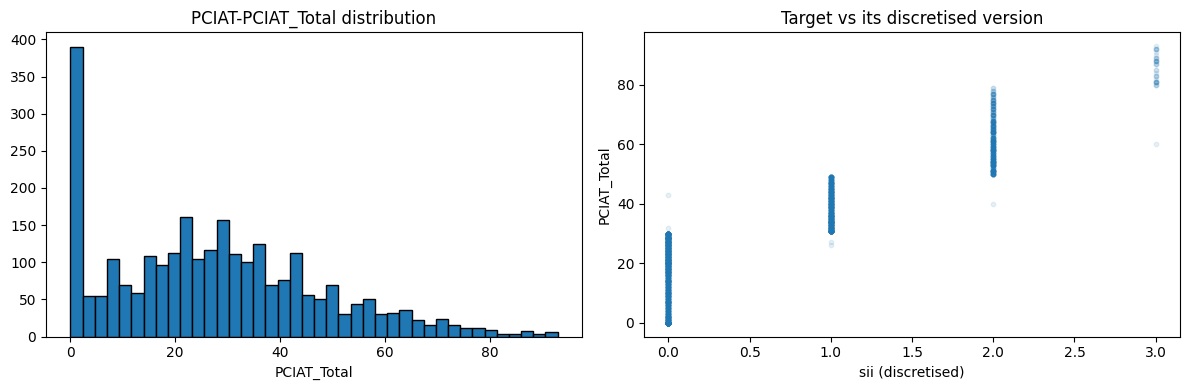

In [ ]:
# Visualise the target distribution — decide if transformation is needed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_reg, bins=40, edgecolor='black')
axes[0].set_title(f'{REG_TARGET} distribution')
axes[0].set_xlabel('PCIAT_Total')

axes[1].scatter(data.loc[reg_mask, 'sii'], y_reg, alpha=0.1, s=10)
axes[1].set_xlabel('sii (discretised)'); axes[1].set_ylabel('PCIAT_Total')
axes[1].set_title('Target vs its discretised version')
plt.tight_layout()
plt.show()

In [ ]:
# How many records actually violate the clean threshold boundaries?
bounds = {0: (0, 30), 1: (31, 49), 2: (50, 79), 3: (80, 93)}
sii_vals = data.loc[reg_mask, 'sii']

violations = 0
for cls, (lo, hi) in bounds.items():
    mask = sii_vals == cls
    out = ((y_reg[mask] < lo) | (y_reg[mask] > hi)).sum()
    print(f"sii={cls}: {out} of {mask.sum()} records outside [{lo}, {hi}]")
    violations += out
print(f"\nTotal violations: {violations} of {len(y_reg)} ({violations/len(y_reg)*100:.2f}%)")

sii=0: 2 of 1585 records outside [0, 30]
sii=1: 2 of 724 records outside [31, 49]
sii=2: 1 of 370 records outside [50, 79]
sii=3: 1 of 35 records outside [80, 93]

Total violations: 6 of 2714 (0.22%)


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)
print(f"Train: {len(yr_train)}, Test: {len(yr_test)}")

# Linear baseline for reference (not one of the two required non-linear approaches)
lin = LinearRegression().fit(Xr_train, yr_train)
pred_lin = lin.predict(Xr_test)
print(f"\nLinear baseline: R² = {r2_score(yr_test, pred_lin):.4f}, "
      f"RMSE = {np.sqrt(mean_squared_error(yr_test, pred_lin)):.2f}, "
      f"MAE = {mean_absolute_error(yr_test, pred_lin):.2f}")

Train: 2035, Test: 679

Linear baseline: R² = 0.3147, RMSE = 16.06, MAE = 12.90


In [ ]:
#Random Forest Regressor
rf_reg_grid = {
    'n_estimators': [200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5, 20],
}
rf_reg = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                      rf_reg_grid, scoring='r2', cv=5)
rf_reg.fit(Xr_train, yr_train)

pred_rf = rf_reg.best_estimator_.predict(Xr_test)
print("Random Forest Regressor")
print(f"  Best params: {rf_reg.best_params_}")
print(f"  CV R²: {rf_reg.best_score_:.4f}")
print(f"  Test R² = {r2_score(yr_test, pred_rf):.4f}, "
      f"RMSE = {np.sqrt(mean_squared_error(yr_test, pred_rf)):.2f}, "
      f"MAE = {mean_absolute_error(yr_test, pred_rf):.2f}")

#Gradient Boosting Regressor
gb_reg_grid = {
    'max_iter': [300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [10, 30],
}
gb_reg = GridSearchCV(HistGradientBoostingRegressor(random_state=42),
                      gb_reg_grid, scoring='r2', cv=5)
gb_reg.fit(Xr_train, yr_train)

pred_gb = gb_reg.best_estimator_.predict(Xr_test)
print("\nGradient Boosting Regressor")
print(f"  Best params: {gb_reg.best_params_}")
print(f"  CV R²: {gb_reg.best_score_:.4f}")
print(f"  Test R² = {r2_score(yr_test, pred_gb):.4f}, "
      f"RMSE = {np.sqrt(mean_squared_error(yr_test, pred_gb)):.2f}, "
      f"MAE = {mean_absolute_error(yr_test, pred_gb):.2f}")

Random Forest Regressor
  Best params: {'max_depth': 20, 'min_samples_leaf': 20, 'n_estimators': 200}
  CV R²: 0.2499
  Test R² = 0.2880, RMSE = 16.37, MAE = 13.09

Gradient Boosting Regressor
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 300, 'min_samples_leaf': 30}
  CV R²: 0.2420
  Test R² = 0.2999, RMSE = 16.24, MAE = 12.82


Linear               CV R² = 0.2433 ± 0.0134
Random Forest        CV R² = 0.2499 ± 0.0379
Gradient Boosting    CV R² = 0.2420 ± 0.0204


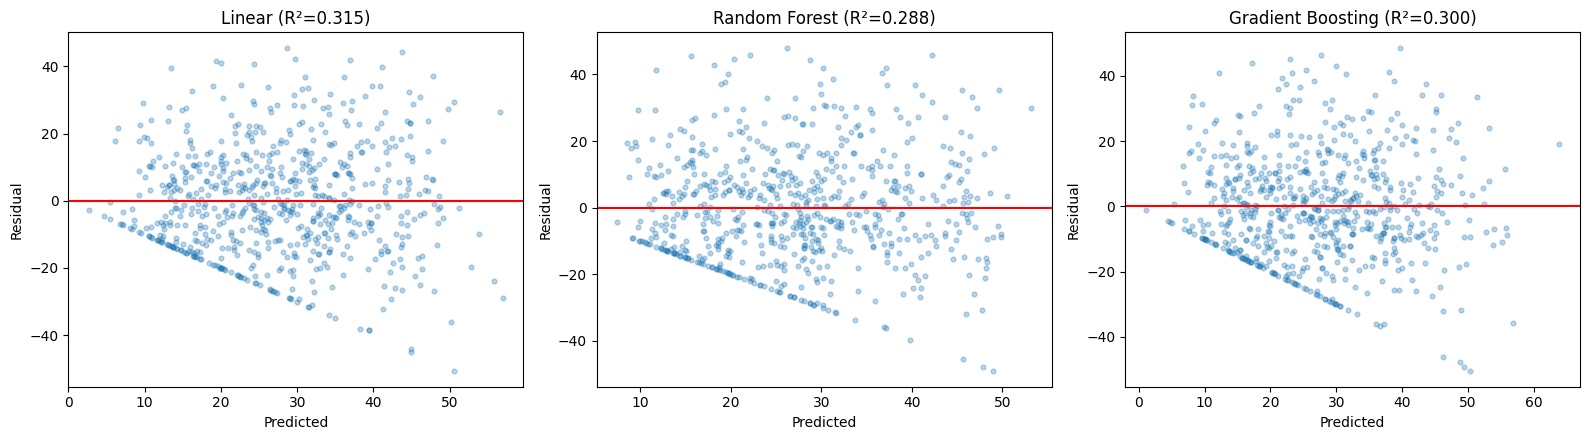

In [ ]:
# Does the linear model's advantage hold under cross-validation, or is it a lucky test split?
from sklearn.model_selection import cross_val_score

for name, model in [('Linear', LinearRegression()),
                    ('Random Forest', rf_reg.best_estimator_),
                    ('Gradient Boosting', gb_reg.best_estimator_)]:
    scores = cross_val_score(model, Xr_train, yr_train, scoring='r2', cv=5)
    print(f"{name:20s} CV R² = {scores.mean():.4f} ± {scores.std():.4f}")

# Is the relationship genuinely linear? Check residual patterns
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pred) in zip(axes, [('Linear', pred_lin),
                                     ('Random Forest', pred_rf),
                                     ('Gradient Boosting', pred_gb)]):
    resid = yr_test - pred
    ax.scatter(pred, resid, alpha=0.3, s=12)
    ax.axhline(0, color='red', lw=1.5)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
    ax.set_title(f'{name} (R²={r2_score(yr_test, pred):.3f})')
plt.tight_layout()
plt.savefig(f'{REPORTS}/regression_residuals.png', dpi=150)
plt.show()

In [ ]:
# Confirm the diagonal edge is the zero-floor effect
zero_mask = yr_test == 0
print(f"Test records with PCIAT_Total = 0: {zero_mask.sum()} of {len(yr_test)}")
print(f"\nPredictions for those records (Linear):")
print(pd.Series(pred_lin[zero_mask]).describe().round(2))

print(f"\nMAE on zero-target records:  {mean_absolute_error(yr_test[zero_mask], pred_lin[zero_mask]):.2f}")
print(f"MAE on non-zero records:     {mean_absolute_error(yr_test[~zero_mask], pred_lin[~zero_mask]):.2f}")

Test records with PCIAT_Total = 0: 81 of 679

Predictions for those records (Linear):
count    81.00
mean     18.85
std       8.89
min       2.70
25%      12.91
50%      17.26
75%      23.45
max      50.55
dtype: float64

MAE on zero-target records:  18.85
MAE on non-zero records:     12.10


In [ ]:
# Would clipping help at all? (Check how many predictions fall outside [0, 93])
for name, pred in [('Linear', pred_lin), ('Random Forest', pred_rf), ('Gradient Boosting', pred_gb)]:
    below = (pred < 0).sum()
    above = (pred > 93).sum()
    print(f"{name:20s} predictions < 0: {below},  > 93: {above}")

Linear               predictions < 0: 0,  > 93: 0
Random Forest        predictions < 0: 0,  > 93: 0
Gradient Boosting    predictions < 0: 0,  > 93: 0


In [ ]:
# Does the model perform better when the zero-inflated group is excluded?
nonzero_train = yr_train > 0
nonzero_test = yr_test > 0

lin_nz = LinearRegression().fit(Xr_train[nonzero_train], yr_train[nonzero_train])
pred_nz = lin_nz.predict(Xr_test[nonzero_test])

print(f"Linear, all records:        R² = {r2_score(yr_test, pred_lin):.4f}")
print(f"Linear, non-zero only:      R² = {r2_score(yr_test[nonzero_test], pred_nz):.4f}")
print(f"Training records: {nonzero_train.sum()} of {len(yr_train)}")

Linear, all records:        R² = 0.3147
Linear, non-zero only:      R² = 0.2801
Training records: 1807 of 2035


In [ ]:
# Final comparison table for the report
reg_summary = pd.DataFrame({
    'Linear Regression': {
        'CV R²': 0.2433, 'CV std': 0.0134,
        'Test R²': r2_score(yr_test, pred_lin),
        'Test RMSE': np.sqrt(mean_squared_error(yr_test, pred_lin)),
        'Test MAE': mean_absolute_error(yr_test, pred_lin),
    },
    'Random Forest': {
        'CV R²': 0.2499, 'CV std': 0.0379,
        'Test R²': r2_score(yr_test, pred_rf),
        'Test RMSE': np.sqrt(mean_squared_error(yr_test, pred_rf)),
        'Test MAE': mean_absolute_error(yr_test, pred_rf),
    },
    'Gradient Boosting': {
        'CV R²': 0.2420, 'CV std': 0.0204,
        'Test R²': r2_score(yr_test, pred_gb),
        'Test RMSE': np.sqrt(mean_squared_error(yr_test, pred_gb)),
        'Test MAE': mean_absolute_error(yr_test, pred_gb),
    },
}).T
print(reg_summary.round(4))

                    CV R²  CV std  Test R²  Test RMSE  Test MAE
Linear Regression  0.2433  0.0134   0.3147    16.0636   12.9036
Random Forest      0.2499  0.0379   0.2880    16.3733   13.0853
Gradient Boosting  0.2420  0.0204   0.2999    16.2360   12.8179


## Advanced Regression

### Task definition

`PCIAT-PCIAT_Total` — the raw summed score of the internet addiction
questionnaire, on a 0–93 scale — is used as the regression target, predicted
from the same 32 physical, demographic and questionnaire features used in the
classification task. The choice is deliberate: `sii` is the discretisation of
this score (Module 0 established the mapping is deterministic in all but six
of 2,714 records), so classification and regression address the same
substantive question — whether problematic internet use can be inferred from
physiology — differing only in whether discretisation occurs before training
or after prediction.

The task is restricted to the 2,714 children with an observed `PCIAT_Total`,
32% of the dataset. This subset is not random: Module 0 documented that PCIAT
is administered more often where a concern already existed, so results
generalise to assessed children rather than to the population.

**The continuous scale retains signal the four-class discretisation destroys.**
Feature correlations with `PCIAT_Total` reach 0.409 (`Basic_Demos-Age`), 0.406
(`Physical-Height`) and 0.366 (`hours/day`), against a maximum of 0.236 for any
feature against `sii`. Collapsing the score into four bands roughly halves the
strongest available correlation.

### Results

Two non-linear approaches were tuned by cross-validated R², with linear
regression included as a reference point rather than as one of the required
methods.

| Model | CV R² | CV std | Test R² | Test RMSE | Test MAE |
|---|---|---|---|---|---|
| Linear Regression | 0.2433 | 0.0134 | **0.3147** | **16.06** | 12.90 |
| Random Forest | **0.2499** | 0.0379 | 0.2880 | 16.37 | 13.09 |
| Gradient Boosting | 0.2420 | 0.0204 | 0.2999 | 16.24 | **12.82** |

On the test split linear regression appears best, outperforming both ensembles.
Cross-validation contradicts this: all three lie between 0.242 and 0.250 with
standard deviations (0.013–0.038) that fully absorb the differences. The
apparent linear advantage is an artefact of one particular 679-record test
split, and a single split is too unstable to rank models separated by 0.03 R².

**Neither non-linear approach improves on the linear baseline.** This inverts
the finding from the DM1 project, where ensembles added 0.077 R² over a linear
model, and two explanations are consistent with the evidence. The sample is
small relative to dimensionality — 2,035 training records for 32 features,
about 64 observations per feature — and cross-validation pushed both ensembles
towards their most conservative settings (`min_samples_leaf` of 20 and 30,
`max_depth=3` for Gradient Boosting), indicating they were fitting noise at any
greater complexity. And the underlying relationships are close to linear: the
strongest predictors correlate monotonically and positively with the target,
with no threshold effects or non-monotonic structure for a tree to exploit.

### Residual analysis

The residual plots show a sharp diagonal boundary at the lower edge for all
three models, produced by the target's floor at zero. 389 children (14% of the
subset) score exactly 0 on PCIAT, and for these the residual equals minus the
prediction by construction, placing them on a perfect line.

These records are systematically mispredicted: MAE on the 81 zero-target test
records is 18.85 against 12.10 on the rest, and no model ever predicts below
2.70 for them. Clipping predictions to [0, 93] would change nothing — all
predictions already fall inside that range. The issue is not boundary violation
but that a zero PCIAT score represents a qualitatively different state (a parent
answered "never" to all twenty items) rather than the low end of a continuum,
and a regression model fitted on continuous predictors cannot produce an exact
zero.

Excluding the zero-inflated group was tested and **reduced** R² from 0.315 to
0.280. Removing them eliminates a large portion of the target's variance along
with the difficult cases, and although the model predicts them poorly in
absolute terms it still ranks them correctly at the low end — their
contribution to explained variance outweighs their contribution to error.

### Conclusion

Three methodologically distinct approaches converge on cross-validated
R² ≈ 0.25 with overlapping confidence intervals. The ceiling is a property of
the data rather than of model choice: physical and anthropometric measurements
account for roughly a quarter of the variation in a child's internet addiction
score, and no change of functional form recovers more. This is consistent with
the classification result, where five algorithms converged on macro F1 ≈ 0.28–0.35,
and with the Random Forest feature importances, which distribute influence
evenly across all 32 features with no single predictor exceeding 6%.

In [ ]:
!pip install -q shap

import shap
print("SHAP version:", shap.__version__)

rf_model = rf_search.best_estimator_

# TreeExplainer computes exact Shapley values for tree ensembles
explainer = shap.TreeExplainer(rf_model)

# Use a sample of the test set — SHAP on all 2115 × 4 classes is slow
sample_idx = np.random.RandomState(42).choice(len(X_test), size=300, replace=False)
X_shap = X_test.iloc[sample_idx]

shap_values = explainer.shap_values(X_shap)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP version: 0.52.0
SHAP values shape: (300, 32, 4)


In [ ]:
class_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

# Mean absolute SHAP value per feature, per class
shap_importance = pd.DataFrame(
    np.abs(shap_values).mean(axis=0),   # (32 features, 4 classes)
    index=classification_features,
    columns=class_names
)
shap_importance['overall'] = shap_importance.mean(axis=1)

print("Top 15 features by mean |SHAP| (averaged across classes):")
print(shap_importance.sort_values('overall', ascending=False).head(15).round(4))

Top 15 features by mean |SHAP| (averaged across classes):
                                         sii=0   sii=1   sii=2   sii=3  \
SDS-SDS_Total_Raw                       0.0276  0.0106  0.0156  0.0124   
Physical-Height                         0.0289  0.0057  0.0106  0.0192   
PreInt_EduHx-computerinternet_hoursday  0.0278  0.0068  0.0160  0.0135   
Basic_Demos-Age                         0.0244  0.0055  0.0121  0.0173   
Physical-Weight                         0.0201  0.0083  0.0081  0.0138   
BIA-BIA_SMM                             0.0123  0.0051  0.0138  0.0070   
CGAS-CGAS_Score                         0.0085  0.0098  0.0077  0.0099   
Physical-BMI                            0.0086  0.0074  0.0042  0.0133   
Physical-Systolic_BP                    0.0096  0.0054  0.0055  0.0122   
BIA-BIA_TBW                             0.0104  0.0061  0.0065  0.0095   
BIA-BIA_ICW                             0.0110  0.0057  0.0073  0.0061   
Physical-HeartRate                      0.0069  0.0087

In [ ]:
comparison_imp = pd.DataFrame({
    'SHAP': shap_importance['overall'],
    'impurity': pd.Series(rf_model.feature_importances_, index=classification_features),
})
comparison_imp['shap_rank'] = comparison_imp['SHAP'].rank(ascending=False).astype(int)
comparison_imp['imp_rank'] = comparison_imp['impurity'].rank(ascending=False).astype(int)
comparison_imp['rank_diff'] = comparison_imp['shap_rank'] - comparison_imp['imp_rank']

print("\nFeatures where the two rankings disagree most:")
print(comparison_imp.reindex(comparison_imp['rank_diff'].abs().sort_values(ascending=False).index)
      .head(10).round(4))

print(f"\nSpearman correlation between the two rankings: "
      f"{comparison_imp['SHAP'].corr(comparison_imp['impurity'], method='spearman'):.3f}")


Features where the two rankings disagree most:
                                          SHAP  impurity  shap_rank  imp_rank  \
PreInt_EduHx-computerinternet_hoursday  0.0160    0.0317          3        17   
Basic_Demos-Sex                         0.0043    0.0109         23        30   
FGC-FGC_CU                              0.0063    0.0282         14        20   
FGC-FGC_GSND                            0.0050    0.0317         21        15   
BIA-BIA_ECW                             0.0055    0.0356         18        12   
BIA-BIA_DEE                             0.0069    0.0406         13         7   
Physical-BMI                            0.0084    0.0474          8         4   
CGAS-CGAS_Score                         0.0090    0.0381          7        11   
FGC-FGC_TL                              0.0044    0.0201         22        26   
PAQ_C-PAQ_C_Total                       0.0059    0.0278         17        21   

                                        rank_diff  
PreInt_E

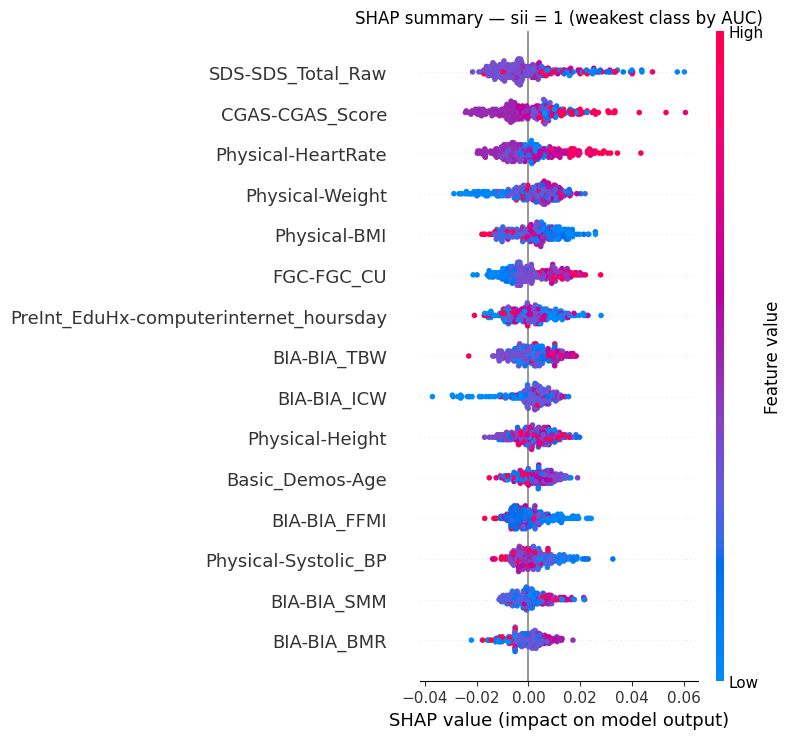

In [ ]:
# Class 1 had the worst ROC-AUC (0.652) — what does the model actually use for it?
shap.summary_plot(shap_values[:, :, 1], X_shap,
                  feature_names=classification_features, show=False, max_display=15)
plt.title("SHAP summary — sii = 1 (weakest class by AUC)")
plt.tight_layout()
plt.savefig(f'{REPORTS}/shap_summary_class1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Explain one individual prediction — pick a correctly-classified severe case
test_reset = y_test.reset_index(drop=True)
correct_severe = [i for i in sample_idx
                  if test_reset.iloc[i] >= 2 and y_pred_rf[i] == test_reset.iloc[i]]
print(f"Correctly classified severe cases in sample: {len(correct_severe)}")

if correct_severe:
    case = correct_severe[0]
    pos = list(sample_idx).index(case)
    true_cls = int(test_reset.iloc[case])

    print(f"\nCase {case}: true sii={true_cls}, predicted={y_pred_rf[case]}")
    print(f"Predicted probabilities: {rf_model.predict_proba(X_test.iloc[[case]])[0].round(3)}")

    contrib = pd.DataFrame({
        'value': X_shap.iloc[pos],
        'shap': shap_values[pos, :, true_cls],
    }).sort_values('shap', key=abs, ascending=False)
    print(f"\nTop 10 contributions towards class {true_cls}:")
    print(contrib.head(10).round(3))

Correctly classified severe cases in sample: 19

Case 1064: true sii=2, predicted=2
Predicted probabilities: [0.287 0.279 0.4   0.033]

Top 10 contributions towards class 2:
                                          value   shap
FGC-FGC_TL                                3.000  0.028
Basic_Demos-Age                          16.000  0.027
CGAS-CGAS_Score                          80.000  0.017
FGC-FGC_GSND                             24.400  0.016
Physical-Height                          66.420  0.014
PreInt_EduHx-computerinternet_hoursday    2.000  0.013
BIA-BIA_TBW                              46.068  0.012
FGC-FGC_GSD                              34.250  0.011
SDS-SDS_Total_Raw                        39.500 -0.010
Physical-Weight                         133.600  0.008


In [ ]:
# Verify the counterintuitive CGAS direction across the whole sample
cgas_shap = shap_values[:, classification_features.index('CGAS-CGAS_Score'), :]
cgas_vals = X_shap['CGAS-CGAS_Score'].values

print("Correlation between CGAS value and its SHAP contribution, per class:")
for cls in range(4):
    r = np.corrcoef(cgas_vals, cgas_shap[:, cls])[0, 1]
    print(f"  class {cls}: r = {r:+.3f}")

Correlation between CGAS value and its SHAP contribution, per class:
  class 0: r = +0.342
  class 1: r = +0.212
  class 2: r = +0.033
  class 3: r = -0.442


## Explainability

SHAP (SHapley Additive exPlanations) was applied to the Random Forest
classifier — the best model by macro F1 and macro ROC-AUC — using
`TreeExplainer`, which computes exact Shapley values for tree ensembles rather
than the sampling approximation required for model-agnostic explainers. Values
were computed on a random 300-record subsample of the test set, producing an
array of shape (300 samples × 32 features × 4 classes).

### Global importance: SHAP against impurity importance

The two rankings agree broadly (Spearman ρ = 0.893) but diverge in one case
that matters.

| Feature | SHAP rank | Impurity rank | Difference |
|---|---|---|---|
| `PreInt_EduHx-computerinternet_hoursday` | 3 | 17 | **−14** |
| `Basic_Demos-Sex` | 23 | 30 | −7 |
| `FGC-FGC_CU` | 14 | 20 | −6 |
| `BIA-BIA_DEE` | 13 | 7 | +6 |
| `BIA-BIA_ECW` | 18 | 12 | +6 |
| `Physical-BMI` | 8 | 4 | +4 |

`PreInt_EduHx-computerinternet_hoursday` — self-reported daily screen time, and
conceptually the feature closest to the target construct in the entire dataset —
ranks third by SHAP and seventeenth by impurity importance. The discrepancy has
a known cause: impurity importance is biased towards features offering many
possible split points, and this variable takes only four discrete values (0–3),
while the features it is outranked by are continuous with thousands. The
features overvalued by impurity importance are all continuous and
high-cardinality, consistent with the same mechanism operating in reverse.

This is the practical case for computing SHAP alongside built-in importances
rather than relying on the latter alone: the single most interpretable predictor
in the dataset was being systematically understated by the default metric.

The top features by mean |SHAP| across classes are `SDS-SDS_Total_Raw` (sleep
disturbance, 0.0166), `Physical-Height` (0.0161), `hours/day` (0.0160) and
`Basic_Demos-Age` (0.0148) — a mixture of one behavioural, one
usage-related and two age-proxy variables. The absolute magnitudes are small:
the most influential feature shifts predicted probability by under 0.02 on
average, quantifying what the aggregate metrics already implied — the signal is
distributed thinly across many weak predictors rather than concentrated in a few
strong ones.

### Direction of effect

SHAP provides signed attributions, which impurity importance cannot. For
`CGAS-CGAS_Score` — a clinical measure of psychosocial functioning where higher
is better — the correlation between feature value and SHAP contribution
decreases monotonically across severity classes:

| Class | sii=0 | sii=1 | sii=2 | sii=3 |
|---|---|---|---|---|
| r(value, SHAP) | +0.342 | +0.212 | +0.033 | **−0.442** |

Better psychosocial functioning pushes predictions towards the unaffected class
and away from the most severe one, which is clinically coherent. More notably,
the gradient is smooth and passes through zero at class 2: the model treats
CGAS as an ordinal indicator of severity despite having been trained on
categorical labels carrying no information about their order.

### Local explanation

One individual prediction illustrates both the method and the model's
limitations. Record 1064 (true `sii` = 2, correctly predicted) received class
probabilities of 0.287 / 0.279 / **0.400** / 0.033 — a correct answer decided
by a margin of 0.11 over the next class, which is representative of the model's
typical confidence at macro F1 0.350 rather than an unusually marginal case.

The largest contributions towards class 2 were `FGC-FGC_TL` = 3 (+0.028),
`Basic_Demos-Age` = 16 (+0.027) and `CGAS-CGAS_Score` = 80 (+0.017), with
`SDS-SDS_Total_Raw` = 39.5 the only meaningful contribution *against* the
predicted class (−0.010). No single feature approaches the magnitude needed to
determine the outcome; the decision is assembled from dozens of contributions
below 0.03 each.

The CGAS contribution in this case initially appeared counterintuitive — a high
functioning score pushing towards a more severe class — but checking the
global pattern showed the correlation for class 2 is 0.033, essentially zero.
The positive contribution here is a local characteristic of this child's
particular feature combination, not a systematic bias. This is a useful
methodological caution: a local explanation describes one prediction and cannot
be extrapolated to the model's global behaviour, which is precisely why both
levels of analysis are needed.